# E-commerce Conversion Prediction
## Notebook 2: Feature Engineering & Model Training

**Models:** Logistic Regression + XGBoost  
**Techniques:** SMOTE, Cross-validation, SHAP, Threshold tuning  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, f1_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/processed/online_shoppers_clean.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


## 2. Feature Engineering

In [3]:
df_fe = df.copy()

# ── Engagement composite score ──────────────────────────────
# Higher product page engagement → stronger purchase intent
df_fe['session_engagement_score'] = (
    df_fe['ProductRelated'] * 0.4 +
    df_fe['ProductRelated_Duration'] / (df_fe['ProductRelated_Duration'].max() + 1) * 0.3 +
    df_fe['PageValues'] / (df_fe['PageValues'].max() + 1) * 0.3
)

# ── Time-on-page ratio ──────────────────────────────────────
total_duration = (df_fe['Administrative_Duration'] +
                  df_fe['Informational_Duration'] +
                  df_fe['ProductRelated_Duration'] + 1e-6)
df_fe['product_time_ratio'] = df_fe['ProductRelated_Duration'] / total_duration

# ── Total pages viewed ──────────────────────────────────────
df_fe['total_pages'] = (df_fe['Administrative'] +
                        df_fe['Informational'] +
                        df_fe['ProductRelated'])

# ── Avg time per product page ───────────────────────────────
df_fe['avg_product_page_time'] = df_fe['ProductRelated_Duration'] / (df_fe['ProductRelated'] + 1)

# ── Bounce-exit interaction ─────────────────────────────────
df_fe['bounce_exit_score'] = df_fe['BounceRates'] * df_fe['ExitRates']

# ── Month encoding (ordered) ────────────────────────────────
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'June': 6,
             'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
df_fe['month_num'] = df_fe['Month'].map(month_map)

# ── Visitor type encoding ───────────────────────────────────
visitor_map = {'Returning_Visitor': 2, 'New_Visitor': 1, 'Other': 0}
df_fe['visitor_type_enc'] = df_fe['VisitorType'].map(visitor_map)

# ── Boolean features → int ──────────────────────────────────
df_fe['Weekend'] = df_fe['Weekend'].astype(int)
df_fe['Revenue'] = df_fe['Revenue'].astype(int)

print('Feature engineering complete.')
print(f'New features added: session_engagement_score, product_time_ratio, total_pages,'
      f' avg_product_page_time, bounce_exit_score, month_num, visitor_type_enc')

Feature engineering complete.
New features added: session_engagement_score, product_time_ratio, total_pages, avg_product_page_time, bounce_exit_score, month_num, visitor_type_enc


In [4]:
# Final feature selection
FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType',
    'Weekend',
    # Engineered
    'session_engagement_score', 'product_time_ratio', 'total_pages',
    'avg_product_page_time', 'bounce_exit_score', 'month_num', 'visitor_type_enc'
]
TARGET = 'Revenue'

X = df_fe[FEATURES]
y = df_fe[TARGET]

print(f'Features: {len(FEATURES)}')
print(f'Positive class: {y.sum()} ({y.mean()*100:.1f}%)')

Features: 22
Positive class: 1908 (15.5%)


## 3. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train positive rate: {y_train.mean()*100:.1f}% | Test positive rate: {y_test.mean()*100:.1f}%')

Train: 9864 samples | Test: 2466 samples
Train positive rate: 15.5% | Test positive rate: 15.5%


## 4. Model 1 — Logistic Regression (with SMOTE)

In [6]:
lr_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv_scores = cross_val_score(lr_pipeline, X_train, y_train,
                               cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'Logistic Regression — CV ROC-AUC: {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

# Fit on full training set
lr_pipeline.fit(X_train, y_train)

# Test set evaluation
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred = lr_pipeline.predict(X_test)
lr_auc = roc_auc_score(y_test, lr_proba)

print(f'\nTest ROC-AUC: {lr_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['No Purchase', 'Purchase']))

Logistic Regression — CV ROC-AUC: 0.8792 ± 0.0038

Test ROC-AUC: 0.8673

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.94      0.88      0.91      2084
    Purchase       0.52      0.69      0.60       382

    accuracy                           0.85      2466
   macro avg       0.73      0.79      0.75      2466
weighted avg       0.88      0.85      0.86      2466



## 5. Model 2 — XGBoost (with scale_pos_weight)

In [7]:
# Handle class imbalance via scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos = neg_count / pos_count
print(f'scale_pos_weight = {scale_pos:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Cross-validation
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train,
                                cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'XGBoost — CV ROC-AUC: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')

# Fit
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print(f'\nTest ROC-AUC: {xgb_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['No Purchase', 'Purchase']))

scale_pos_weight = 5.46


XGBoost — CV ROC-AUC: 0.9309 ± 0.0049



Test ROC-AUC: 0.9258

Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92      2084
    Purchase       0.57      0.79      0.66       382

    accuracy                           0.88      2466
   macro avg       0.77      0.84      0.79      2466
weighted avg       0.90      0.88      0.88      2466



## 6. Model Comparison — ROC Curves

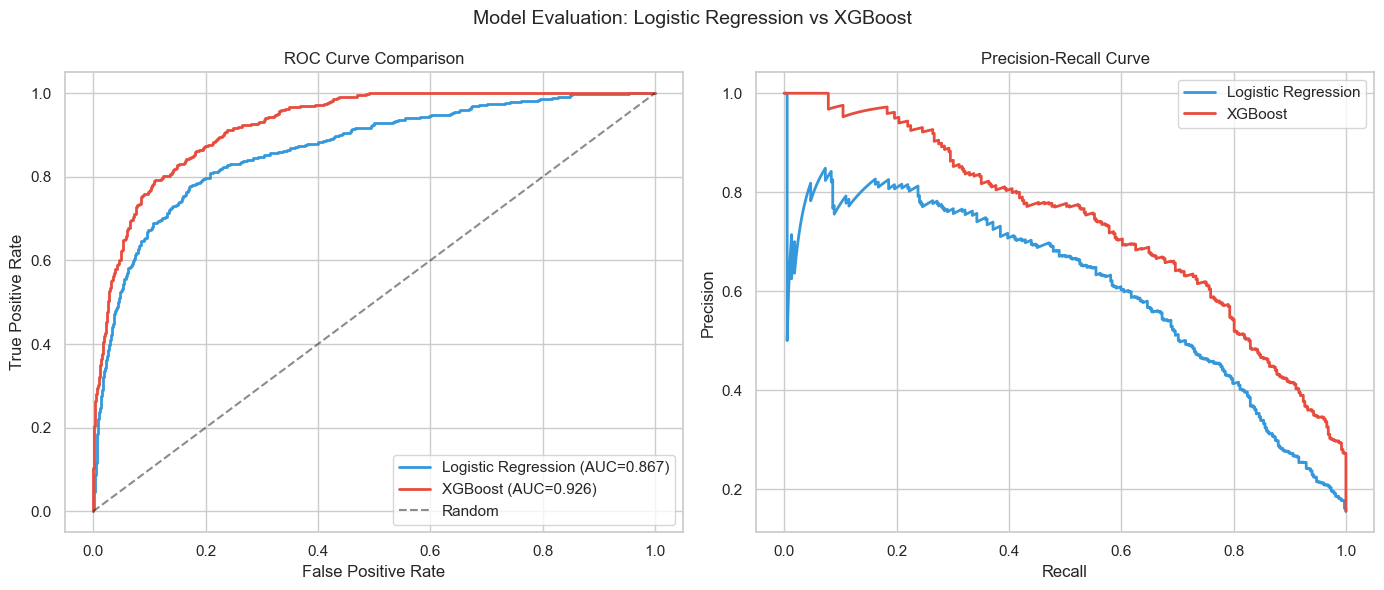

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curves
for proba, label, color in [
    (lr_proba, f'Logistic Regression (AUC={lr_auc:.3f})', '#3498db'),
    (xgb_proba, f'XGBoost (AUC={xgb_auc:.3f})', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=label, color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()

# Precision-Recall curves
for proba, label, color in [
    (lr_proba, 'Logistic Regression', '#3498db'),
    (xgb_proba, 'XGBoost', '#e74c3c')
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=label, color=color, linewidth=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('Model Evaluation: Logistic Regression vs XGBoost', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/fig_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Confusion Matrices

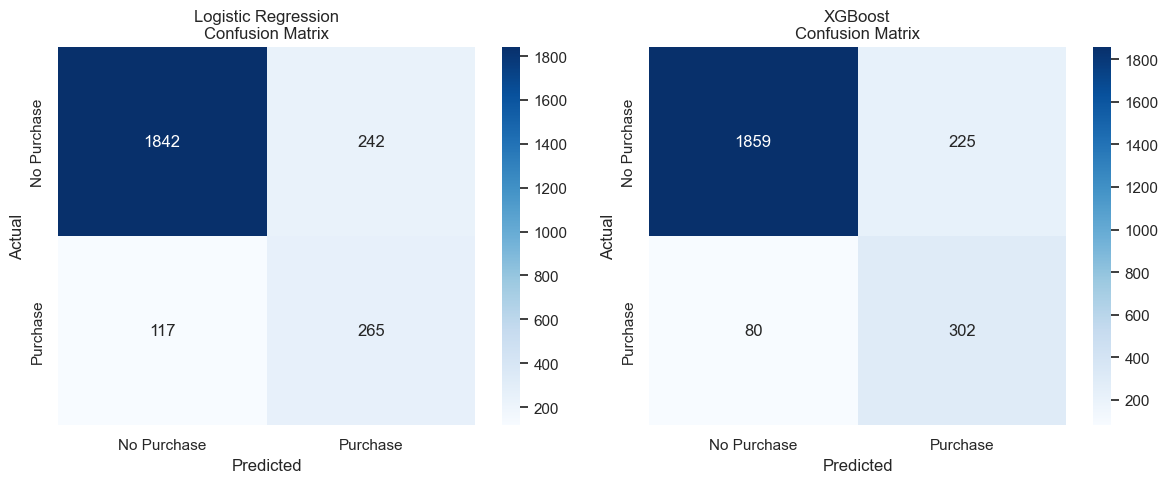

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in [
    (axes[0], lr_pred, 'Logistic Regression'),
    (axes[1], xgb_pred, 'XGBoost')
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    ax.set_title(f'{title}\nConfusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../data/processed/fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. SHAP Feature Importance (XGBoost)

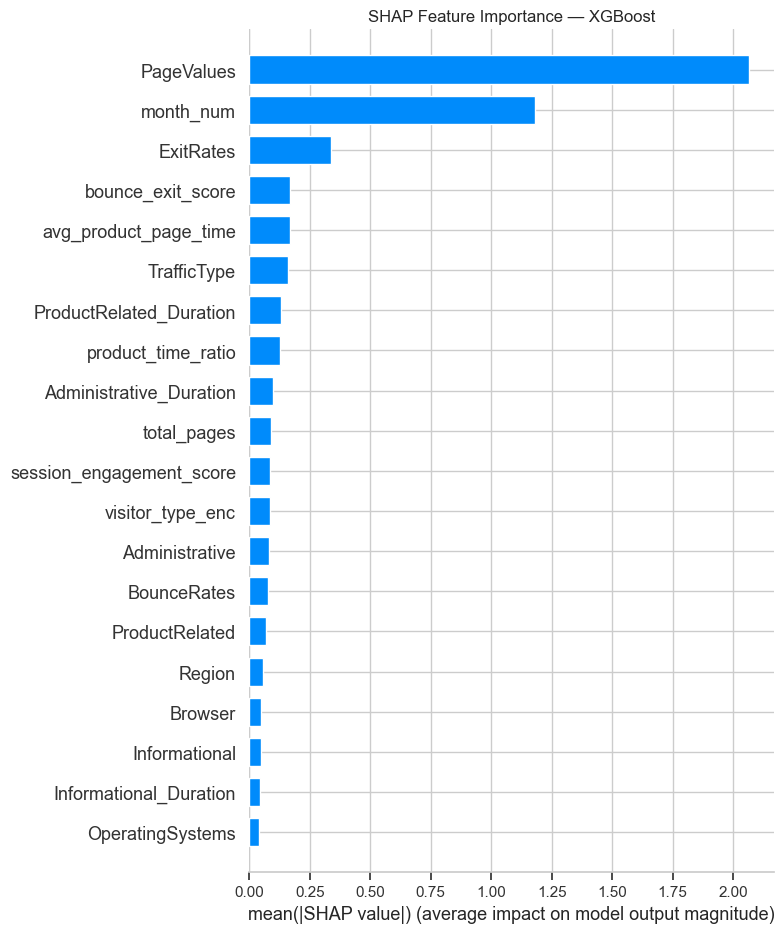

In [10]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

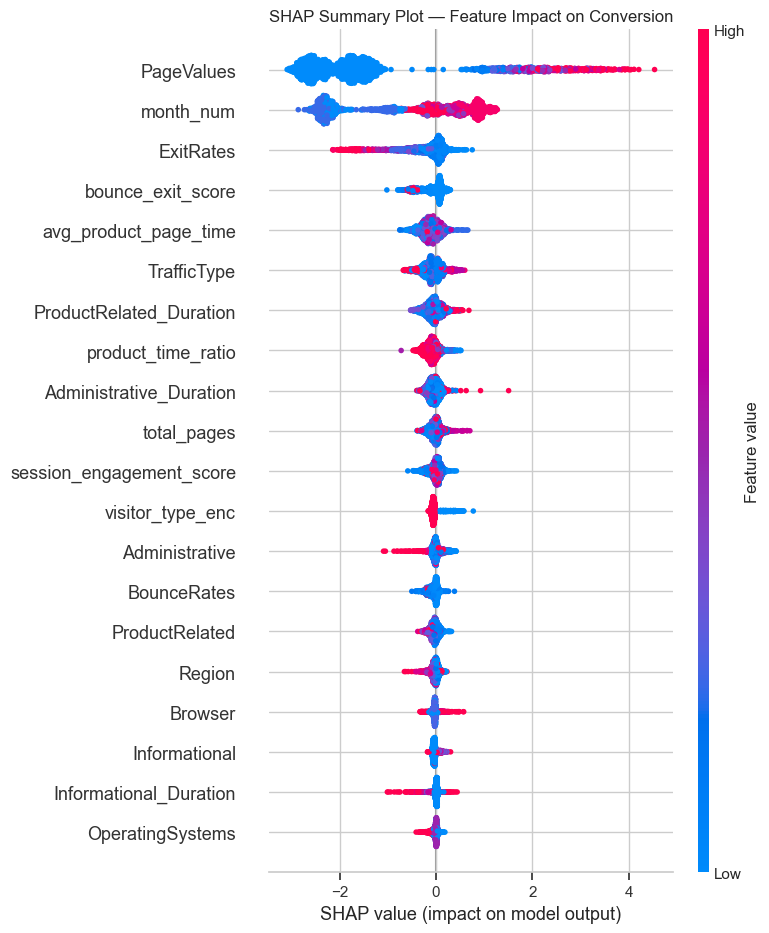

In [11]:
# SHAP beeswarm — shows direction of impact
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Plot — Feature Impact on Conversion')
plt.tight_layout()
plt.savefig('../data/processed/fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Threshold Tuning

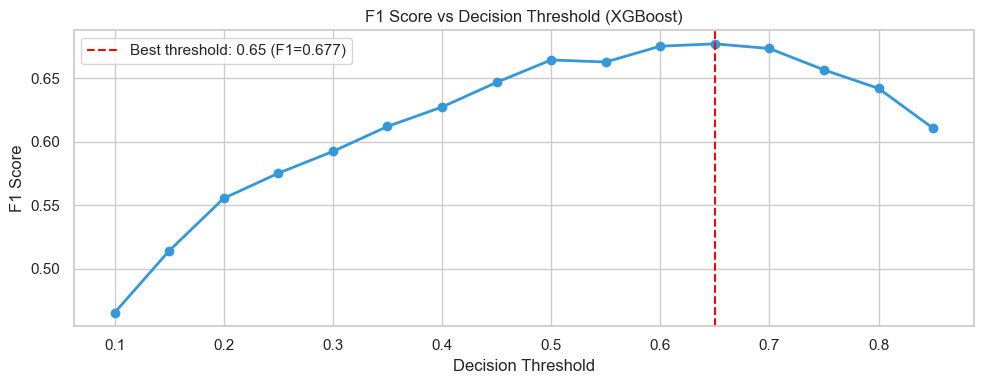

Optimal threshold: 0.65
Best F1 score: 0.6771

Tuned Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2084
    Purchase       0.63      0.73      0.68       382

    accuracy                           0.89      2466
   macro avg       0.79      0.83      0.81      2466
weighted avg       0.90      0.89      0.90      2466



In [12]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test, (xgb_proba >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_scores, marker='o', color='#3498db', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--',
            label=f'Best threshold: {best_threshold:.2f} (F1={best_f1:.3f})')
plt.xlabel('Decision Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold (XGBoost)')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/fig_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold: {best_threshold:.2f}')
print(f'Best F1 score: {best_f1:.4f}')

# Final predictions with tuned threshold
xgb_pred_tuned = (xgb_proba >= best_threshold).astype(int)
print('\nTuned Classification Report:')
print(classification_report(y_test, xgb_pred_tuned, target_names=['No Purchase', 'Purchase']))

## 10. Save Model & Artifacts

In [13]:
os.makedirs('../app/model', exist_ok=True)

# Save XGBoost model (best performer)
with open('../app/model/xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save LR pipeline
with open('../app/model/lr_pipeline.pkl', 'wb') as f:
    pickle.dump(lr_pipeline, f)

# Save metadata
model_meta = {
    'features': FEATURES,
    'best_threshold': float(best_threshold),
    'xgb_auc': float(xgb_auc),
    'lr_auc': float(lr_auc),
}
import json
with open('../app/model/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

# Save processed feature matrix
X_train_out = X_train.copy()
X_train_out['Revenue'] = y_train.values
X_train_out.to_csv('../data/processed/train_features.csv', index=False)

print('Saved:')
print('  ../app/model/xgb_model.pkl')
print('  ../app/model/lr_pipeline.pkl')
print('  ../app/model/model_meta.json')
print('  ../data/processed/train_features.csv')

print(f'\n=== FINAL RESULTS ===')
print(f'Logistic Regression ROC-AUC: {lr_auc:.4f}')
print(f'XGBoost ROC-AUC:             {xgb_auc:.4f}')
print(f'Best model: XGBoost (threshold={best_threshold:.2f})')

Saved:
  ../app/model/xgb_model.pkl
  ../app/model/lr_pipeline.pkl
  ../app/model/model_meta.json
  ../data/processed/train_features.csv

=== FINAL RESULTS ===
Logistic Regression ROC-AUC: 0.8673
XGBoost ROC-AUC:             0.9258
Best model: XGBoost (threshold=0.65)
